In [1]:
import pandas as pd

extract_dir = "/home/akash/Downloads/DR_images"

train_df = pd.read_csv(f"{extract_dir}/train.csv")
test_df  = pd.read_csv(f"{extract_dir}/test.csv")

print(len(train_df), len(test_df))


3662 1928


In [2]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import torch

class_names = ['No_DR','Mild','Moderate','Severe','Proliferative']

val_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

class DRDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df = df
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.root}/{row['id_code']}.png").convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, int(row['diagnosis'])


In [4]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define ResNet
resnet = models.resnet34(pretrained=False)

# VERY IMPORTANT — match your training setup
resnet.fc = nn.Linear(resnet.fc.in_features, 5)  # 5 classes for DR


/home/akash/Downloads/dr_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/akash/Downloads/dr_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [5]:
state_dict = torch.load("resnet34.pth", map_location=device)
print(state_dict.keys())

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer1.2.conv1.weight', 'layer1.2.bn1.weight', 'layer1.2.bn1.bias', 'layer1.2.bn1.running_mean', 'layer1.2.bn1.running_var', 'layer1.2.bn1.num_batches_tracked', 'layer1.2.conv2.weight', 'layer1.2.bn2.weight', 'layer1.2.bn2.bias', '

In [6]:
import torch
import torch.nn as nn
from torchvision import models

resnet = models.resnet34()

resnet.fc = nn.Sequential(
    nn.Linear(512, 256),  # fc.0
    nn.Linear(256, 128),  # fc.1  (inferred)
    nn.Linear(128, 64),   # fc.2  (inferred)
    nn.Linear(64, 5)      # fc.3
)

resnet.load_state_dict(torch.load("resnet34.pth", map_location=device))

resnet.to(device)
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:

resnet.load_state_dict(torch.load("resnet34.pth", map_location=device))

resnet.to(device)
resnet.eval()

print("ResNet loaded successfully 🎯")


ResNet loaded successfully 🎯


In [8]:
from torchvision import models
import torch.nn as nn

effnet = models.efficientnet_v2_s(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 5)

effnet.load_state_dict(torch.load("efficientnetv2_dr.pth", map_location=device))
effnet.to(device)
effnet.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [9]:
from torch.utils.data import DataLoader

data_set = DRDataset(train_df, f"{extract_dir}/train_images", transform=val_transform)

train_size = int(len(data_set)*0.9)
valid_size = len(data_set) - train_size

train_set, valid_set = torch.utils.data.random_split(data_set, [train_size, valid_size])

valid_dataloader = DataLoader(valid_set, batch_size=4, shuffle=False)
train_dataloader = DataLoader(train_set, batch_size=4, shuffle=False)

Training Samples: 3662
Testing Samples: 1928


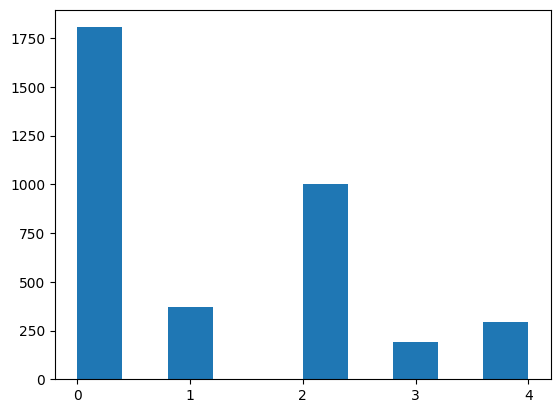

In [10]:
print("Training Samples:", len(train_df))
print("Testing Samples:", len(test_df))



#Histogram of label counts.
train_df.diagnosis.hist()
plt.xticks([0,1,2,3,4])
plt.grid(False)
plt.show()

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

resnet.eval()
effnet.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.inference_mode():
    for x, y in valid_dataloader:

        x = x.to(device)
        y = y.to(device)

        # Get probabilities from both models
        p1 = F.softmax(resnet(x), dim=1)
        p2 = F.softmax(effnet(x), dim=1)

        # Ensemble by averaging
        avg = (p1 + p2) / 2

        # Final predicted class
        preds = avg.argmax(dim=1)

        # Accuracy calculation
        correct += (preds == y).sum().item()
        total += y.size(0)

        # Store for evaluation
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\n⭐ Ensemble Accuracy = {100 * correct / total:.2f}%")




⭐ Ensemble Accuracy = 97.28%


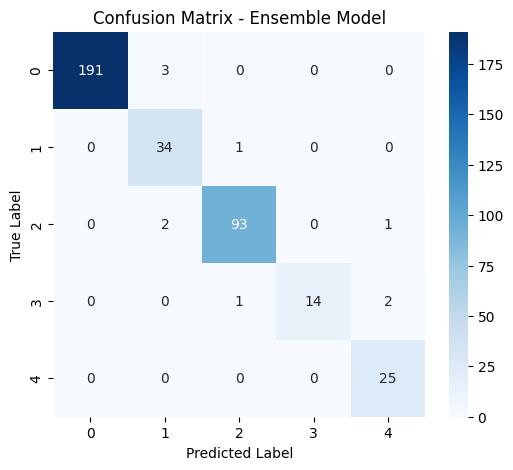

np.True_

In [12]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Ensemble Model")
plt.show()
cm.sum() == total
np.trace(cm) == correct


In [13]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       194
           1       0.87      0.97      0.92        35
           2       0.98      0.97      0.97        96
           3       1.00      0.82      0.90        17
           4       0.89      1.00      0.94        25

    accuracy                           0.97       367
   macro avg       0.95      0.95      0.95       367
weighted avg       0.97      0.97      0.97       367



In [14]:
import torch
import torch.nn.functional as F

def ensemble_train_val_accuracy(resnet, effnet, train_loader, val_loader, device):
    resnet.eval()
    effnet.eval()

    def compute_accuracy(dataloader):
        correct = 0
        total = 0

        with torch.inference_mode():
            for x, y in dataloader:
                x = x.to(device)
                y = y.to(device)

                p1 = F.softmax(resnet(x), dim=1)
                p2 = F.softmax(effnet(x), dim=1)

                avg = (p1 + p2) / 2
                preds = avg.argmax(dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        return 100 * correct / total

    train_acc = compute_accuracy(train_loader)
    val_acc = compute_accuracy(val_loader)

    return train_acc, val_acc

train_acc, val_acc = ensemble_train_val_accuracy(
    resnet, effnet, train_dataloader, valid_dataloader, device
)

print(f"Ensemble Training Accuracy   : {train_acc:.2f}%")
print(f"Ensemble Validation Accuracy : {val_acc:.2f}%")


Ensemble Training Accuracy   : 97.85%
Ensemble Validation Accuracy : 97.28%


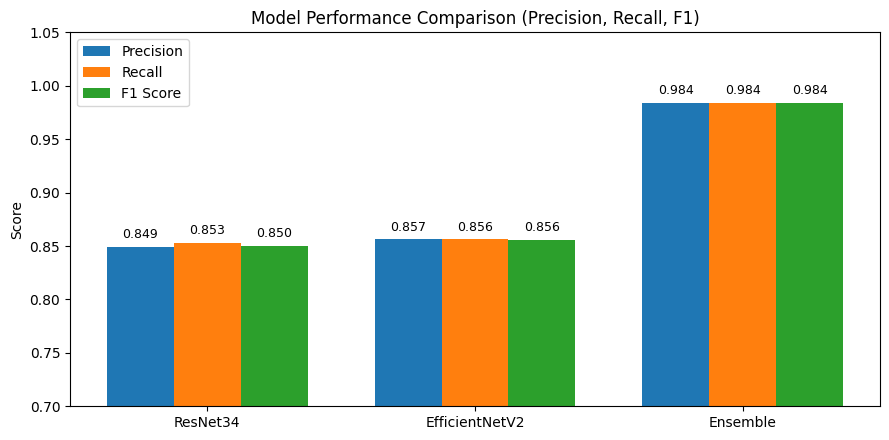

In [15]:
import numpy as np
import matplotlib.pyplot as plt

models = ['ResNet34', 'EfficientNetV2', 'Ensemble']

precision_scores = [0.8494, 0.8565, 0.9840]
recall_scores    = [0.8528, 0.8564, 0.9840]
f1_scores        = [0.8504, 0.8558, 0.9840]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 4.5))   # slightly taller

plt.bar(x - width, precision_scores, width, label='Precision')
plt.bar(x, recall_scores, width, label='Recall')
plt.bar(x + width, f1_scores, width, label='F1 Score')

plt.xticks(x, models)
plt.ylim(0.7, 1.05)            # more headroom
plt.ylabel('Score')
plt.title('Model Performance Comparison (Precision, Recall, F1)')
plt.legend()

# ---- Value labels (adjusted offset) ----
offset = 0.008
for i in range(len(models)):
    plt.text(x[i] - width, precision_scores[i] + offset, f"{precision_scores[i]:.3f}",
             ha='center', fontsize=9)
    plt.text(x[i], recall_scores[i] + offset, f"{recall_scores[i]:.3f}",
             ha='center', fontsize=9)
    plt.text(x[i] + width, f1_scores[i] + offset, f"{f1_scores[i]:.3f}",
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd

extract_dir = "/home/akash/Downloads/DR_images" 
csv_path = f"{extract_dir}/train.csv"

train_df = pd.read_csv(csv_path)

print(train_df.head())


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [17]:
train_split = train_df[:3000]
valid_split = train_df[3000:]


In [18]:
print(len(valid_split))


662


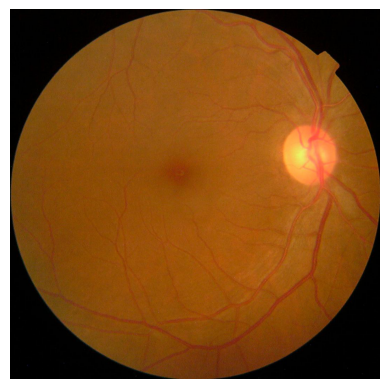

prediction → class 0 - No DR
--------------------------------------------------


In [23]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
import torch

class_names = ['class 0 - No DR','class 1 - Mild','class 2 - Moderate','class 3 - Severe','class 4 - Proliferative']

resnet.eval()
effnet.eval()

samples = valid_split.sample(1).reset_index(drop=True)

for i in range(len(samples)):

    img_id = samples.iloc[i]["id_code"]
    true_label = samples.iloc[i]["diagnosis"]

    img_path = f"DR_images/train_images/0a4e1a29ffff.png"
    img = Image.open(img_path).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    # plt.title(f"True Label: {class_names[true_label]}")
    plt.show()

    x = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        p1 = F.softmax(resnet(x), dim=1)
        p2 = F.softmax(effnet(x), dim=1)

        ensemble = (p1 + p2) / 2

        pred_res = p1.argmax(1).item()
        pred_eff = p2.argmax(1).item()
        pred_final = ensemble.argmax(1).item()

    # print(f"ResNet → {class_names[pred_res]}")
    # print(f"EffNet → {class_names[pred_eff]}")
    print(f"prediction → {class_names[pred_final]}")
    print("-"*50)
